# CodeAlpha Data Analytics Internship

## Movie Market Intelligence

**Intern:** Prathvish K Naik  
**Domain:** Data Analytics  
**Tasks:** Web Scraping, Exploratory Data Analysis, Data Visualization  
**Tools:** Python, Pandas, NumPy, Requests, BeautifulSoup, Matplotlib, Seaborn

### Project Objective

This project collects movie information from a public web source and analyzes the resulting dataset to identify patterns, trends, and insights.

The project follows an end-to-end data analytics workflow:

1. Web Scraping
2. Data Cleaning and Preparation
3. Exploratory Data Analysis
4. Data Visualization
5. Insight Generation

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.scrapethissite.com/pages/ajax-javascript/"

response = requests.get(url, timeout=10)

print("Status code:", response.status_code)
print("Page retrieved successfully:", response.ok)

Status code: 200
Page retrieved successfully: True


In [4]:
year = 2010

url = f"https://www.scrapethissite.com/pages/ajax-javascript/?ajax=true&year={year}"

response = requests.get(url, timeout=10)

print("Status code:", response.status_code)
print("Data received:", response.text[:500])

Status code: 200
Data received: [
  {
    "title": "The King's Speech",
    "year": 2010,
    "awards": 4,
    "nominations": 12,
    "best_picture": true
  },
  {
    "title": "Inception",
    "year": 2010,
    "awards": 4,
    "nominations": 8
  },
  {
    "title": "The Social Network",
    "year": 2010,
    "awards": 3,
    "nominations": 8
  },
  {
    "title": "The Fighter",
    "year": 2010,
    "awards": 2,
    "nominations": 7
  },
  {
    "title": "Toy Story 3",
    "year": 2010,
    "awards": 2,
    "nominations": 5



In [5]:
import json
import time

all_movies = []

for year in range(2010, 2016):
    url = f"https://www.scrapethissite.com/pages/ajax-javascript/?ajax=true&year={year}"
    response = requests.get(url, timeout=10)

    if response.status_code == 200:
        movies = response.json()
        all_movies.extend(movies)
        print(f"{year}: {len(movies)} movies collected")
    else:
        print(f"{year}: Failed")

    time.sleep(1)

print("Total movies collected:", len(all_movies))

2010: 13 movies collected
2011: 15 movies collected
2012: 15 movies collected
2013: 12 movies collected
2014: 16 movies collected
2015: 16 movies collected
Total movies collected: 87


In [1]:
df = pd.DataFrame(all_movies)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

NameError: name 'pd' is not defined

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time

In [3]:
all_movies = []

for year in range(2010, 2016):
    url = f"https://www.scrapethissite.com/pages/ajax-javascript/?ajax=true&year={year}"
    response = requests.get(url, timeout=10)

    if response.status_code == 200:
        movies = response.json()
        all_movies.extend(movies)
        print(f"{year}: {len(movies)} movies collected")
    else:
        print(f"{year}: Failed")

    time.sleep(1)

print("Total movies collected:", len(all_movies))

2010: 13 movies collected
2011: 15 movies collected
2012: 15 movies collected
2013: 12 movies collected
2014: 16 movies collected
2015: 16 movies collected
Total movies collected: 87


In [4]:
df = pd.DataFrame(all_movies)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (87, 5)

Columns:
['title', 'year', 'awards', 'nominations', 'best_picture']

First 5 rows:


,title,year,awards,nominations,best_picture
0,The King's Speech,2010,4,12,True
1,Inception,2010,4,8,NaN
2,The Social Network,2010,3,8,NaN
3,The Fighter,2010,2,7,NaN
4,Toy Story 3,2010,2,5,NaN


In [5]:
df.to_csv("../data/raw/movies_scraped.csv", index=False)

print("Dataset saved successfully.")
print("Rows:", len(df))

Dataset saved successfully.
Rows: 87


In [6]:
import os

file_path = "../data/raw/movies_scraped.csv"

print("File exists:", os.path.exists(file_path))
print("File path:", os.path.abspath(file_path))

File exists: True
File path: C:\Users\naikp\OneDrive\Desktop\CodeAlpha_Data_Analytics\data\raw\movies_scraped.csv


In [7]:
print("Dataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         87 non-null     object
 1   year          87 non-null     int64 
 2   awards        87 non-null     int64 
 3   nominations   87 non-null     int64 
 4   best_picture  6 non-null      object
dtypes: int64(3), object(2)
memory usage: 3.5+ KB

Missing values:
title            0
year             0
awards           0
nominations      0
best_picture    81
dtype: int64

Duplicate rows: 0


In [9]:
df["best_picture"] = df["best_picture"].fillna(False).astype("boolean")

print(df["best_picture"].value_counts())

best_picture
False    81
True      6
Name: count, dtype: Int64


In [10]:
df.to_csv("../data/processed/movies_clean.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset saved successfully.
Rows: 87
Columns: 5


## Task 2 — Exploratory Data Analysis

### Objective
Analyze the scraped movie dataset to identify trends, patterns, relationships, and notable observations.

### Key Questions
1. How did the number of movies change from 2010 to 2015?
2. Which year had the highest total awards?
3. Which movies received the most nominations?
4. Is there a relationship between awards and nominations?
5. How many movies won Best Picture each year?

In [11]:
yearly_summary = df.groupby("year").agg(
    movies=("title", "count"),
    total_awards=("awards", "sum"),
    total_nominations=("nominations", "sum")
).reset_index()

display(yearly_summary)

,year,movies,total_awards,total_nominations
0,2010,13,24,54
1,2011,15,24,50
2,2012,15,25,75
3,2013,12,24,42
4,2014,16,24,63
5,2015,16,24,59


In [12]:
top_nominated = df.sort_values(
    by="nominations",
    ascending=False
)[["title", "year", "nominations", "awards"]].head(10)

display(top_nominated)

,title,year,nominations,awards
0,The King's Speech,2010,12,4
73,The Revenant,2015,12,3
31,Lincoln,2012,12,2
14,Hugo,2011,11,5
29,Life of Pi,2012,11,4
44,Gravity,2013,10,7
13,The Artist,2011,10,5
72,Mad Max: Fury Road,2015,10,6
43,12 Years a Slave,2013,9,3
55,Birdman,2014,9,4


In [13]:
correlation = df["awards"].corr(df["nominations"])

print(f"Correlation between awards and nominations: {correlation:.2f}")

Correlation between awards and nominations: 0.75


In [14]:
best_picture_by_year = df.groupby("year")["best_picture"].sum().reset_index()

best_picture_by_year.columns = ["year", "best_picture_winners"]

display(best_picture_by_year)

,year,best_picture_winners
0,2010,1
1,2011,1
2,2012,1
3,2013,1
4,2014,1
5,2015,1


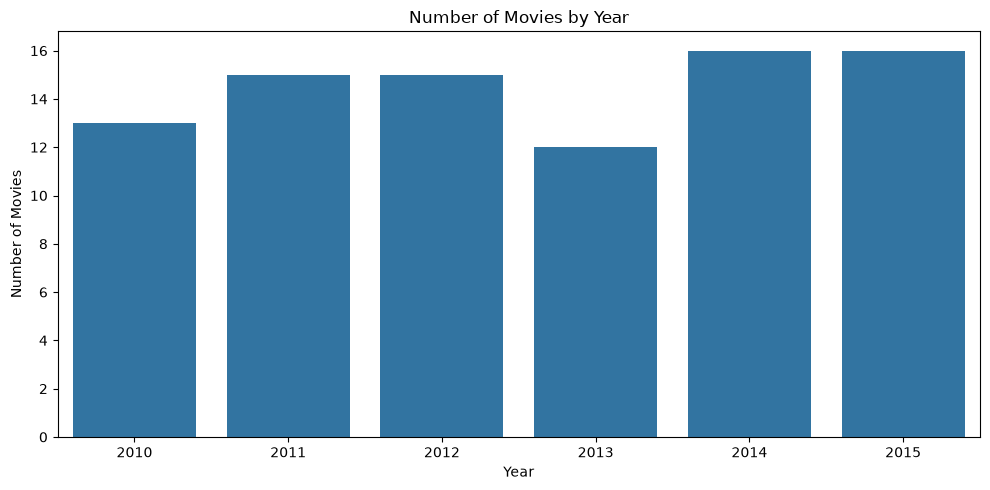

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    data=yearly_summary,
    x="year",
    y="movies"
)

plt.title("Number of Movies by Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

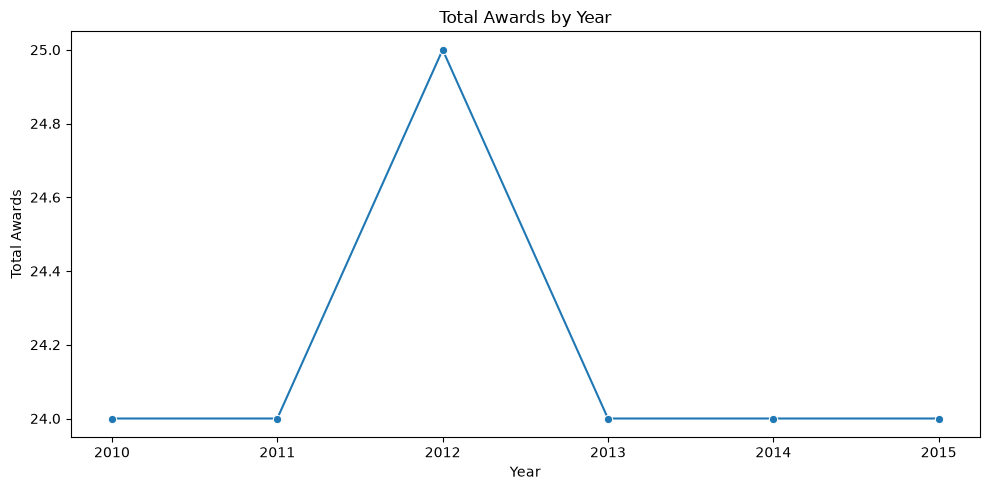

In [16]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yearly_summary,
    x="year",
    y="total_awards",
    marker="o"
)

plt.title("Total Awards by Year")
plt.xlabel("Year")
plt.ylabel("Total Awards")
plt.xticks(yearly_summary["year"])
plt.tight_layout()
plt.show()

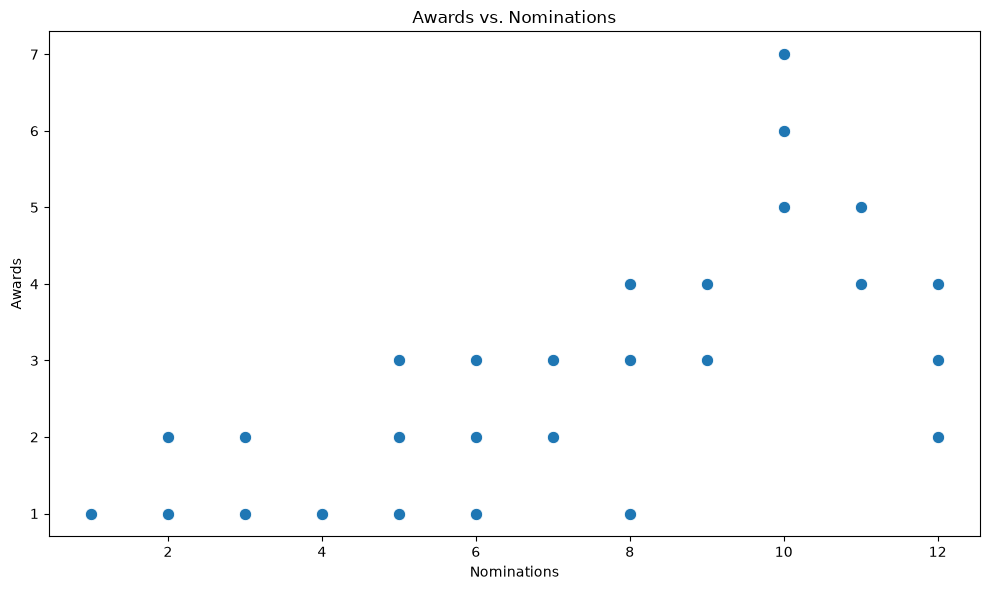

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="nominations",
    y="awards",
    s=80
)

plt.title("Awards vs. Nominations")
plt.xlabel("Nominations")
plt.ylabel("Awards")
plt.tight_layout()
plt.show()

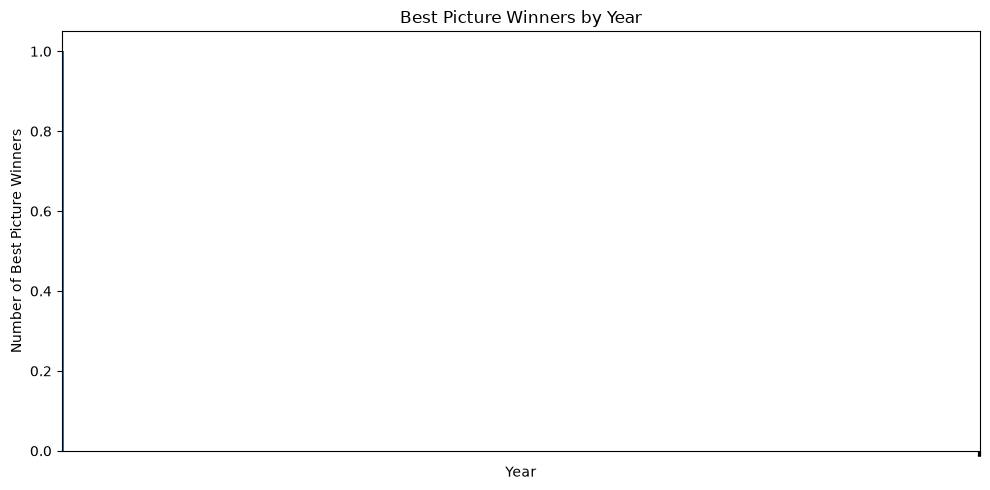

In [18]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=best_picture_by_year,
    x="year",
    y="best_picture_winners"
)

plt.title("Best Picture Winners by Year")
plt.xlabel("Year")
plt.ylabel("Number of Best Picture Winners")
plt.xticks(best_picture_by_year["year"])
plt.tight_layout()
plt.show()

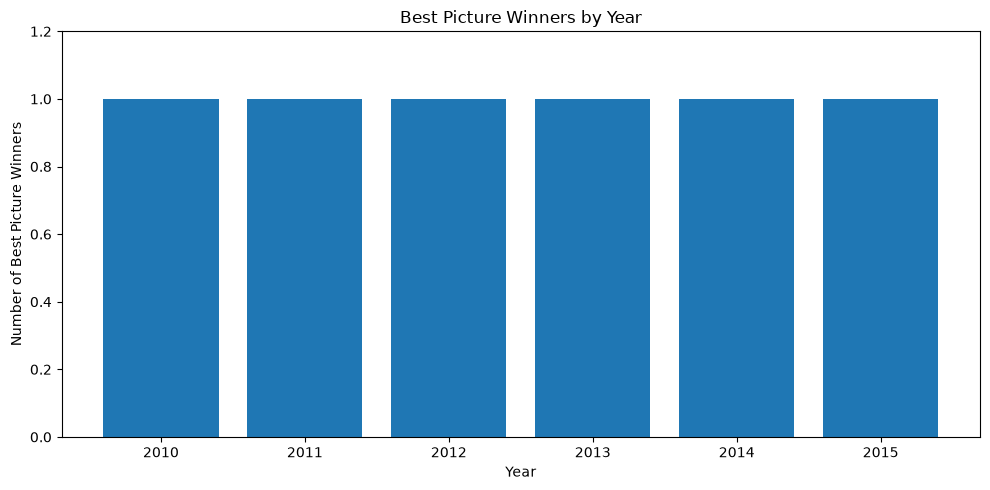

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(
    best_picture_by_year["year"].astype(str),
    best_picture_by_year["best_picture_winners"]
)

plt.title("Best Picture Winners by Year")
plt.xlabel("Year")
plt.ylabel("Number of Best Picture Winners")
plt.ylim(0, 1.2)
plt.tight_layout()
plt.show()

In [20]:
top_awards = df.sort_values(
    by="awards",
    ascending=False
)[["title", "year", "awards", "nominations"]].head(10)

display(top_awards)

,title,year,awards,nominations
44,Gravity,2013,7,10
72,Mad Max: Fury Road,2015,6,10
13,The Artist,2011,5,10
14,Hugo,2011,5,11
55,Birdman,2014,4,9
1,Inception,2010,4,8
0,The King's Speech,2010,4,12
29,Life of Pi,2012,4,11
56,The Grand Budapest Hotel,2014,4,9
43,12 Years a Slave,2013,3,9


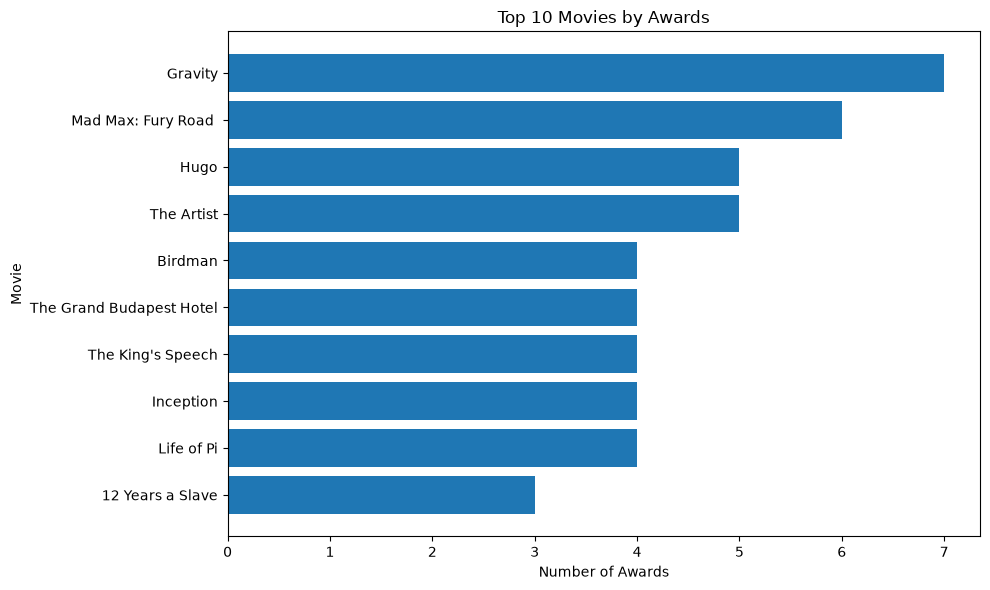

In [21]:
plt.figure(figsize=(10, 6))

top_awards_chart = top_awards.sort_values("awards")

plt.barh(
    top_awards_chart["title"],
    top_awards_chart["awards"]
)

plt.title("Top 10 Movies by Awards")
plt.xlabel("Number of Awards")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()

## Task 3 — Data Visualization

### Objective
Create clear, presentation-ready visualizations that communicate important findings from the movie dataset.

### Visualization Goals
1. Show the yearly movie distribution.
2. Compare awards and nominations.
3. Highlight the highest-awarded movies.
4. Present important findings in a clear data story.

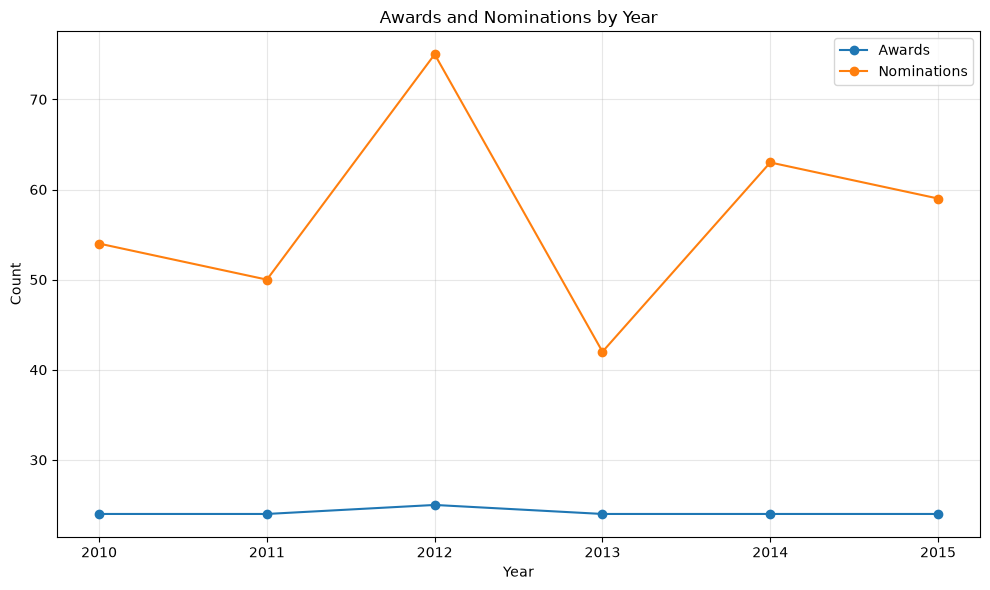

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_summary["year"],
    yearly_summary["total_awards"],
    marker="o",
    label="Awards"
)

plt.plot(
    yearly_summary["year"],
    yearly_summary["total_nominations"],
    marker="o",
    label="Nominations"
)

plt.title("Awards and Nominations by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(yearly_summary["year"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

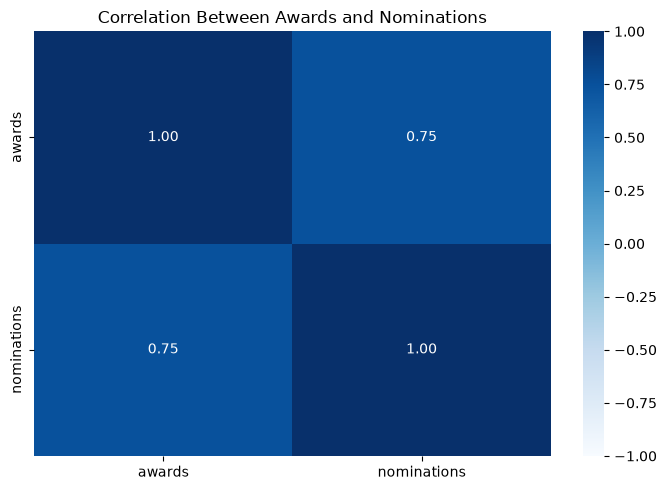

In [23]:
plt.figure(figsize=(7, 5))

correlation_matrix = df[["awards", "nominations"]].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Awards and Nominations")
plt.tight_layout()
plt.show()

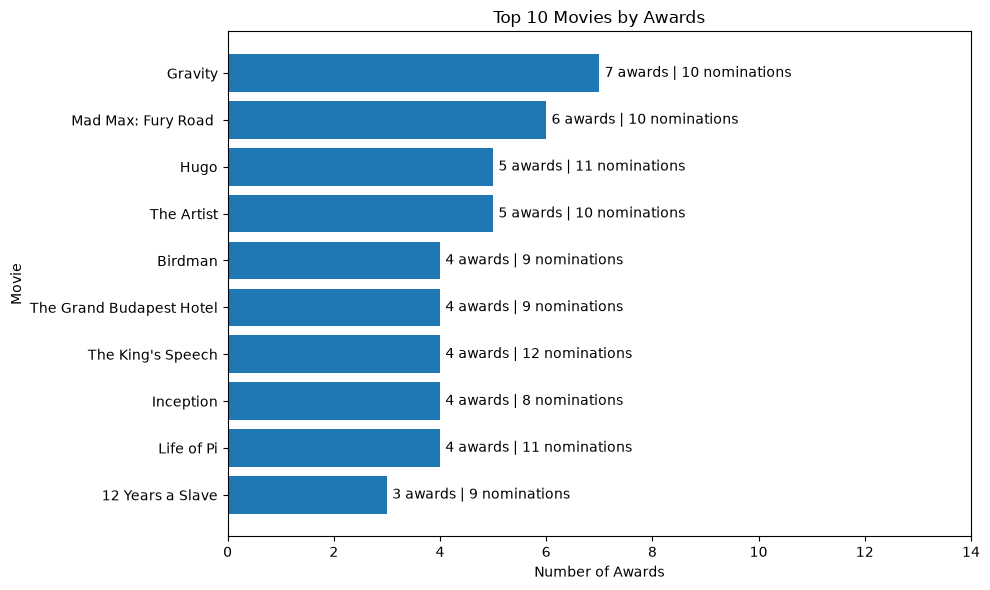

In [24]:
plt.figure(figsize=(10, 6))

top_awards_chart = top_awards.sort_values("awards")

bars = plt.barh(
    top_awards_chart["title"],
    top_awards_chart["awards"]
)

for bar, nominations in zip(
    bars,
    top_awards_chart["nominations"]
):
    plt.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())} awards | {int(nominations)} nominations",
        va="center"
    )

plt.title("Top 10 Movies by Awards")
plt.xlabel("Number of Awards")
plt.ylabel("Movie")
plt.xlim(0, 14)
plt.tight_layout()
plt.show()

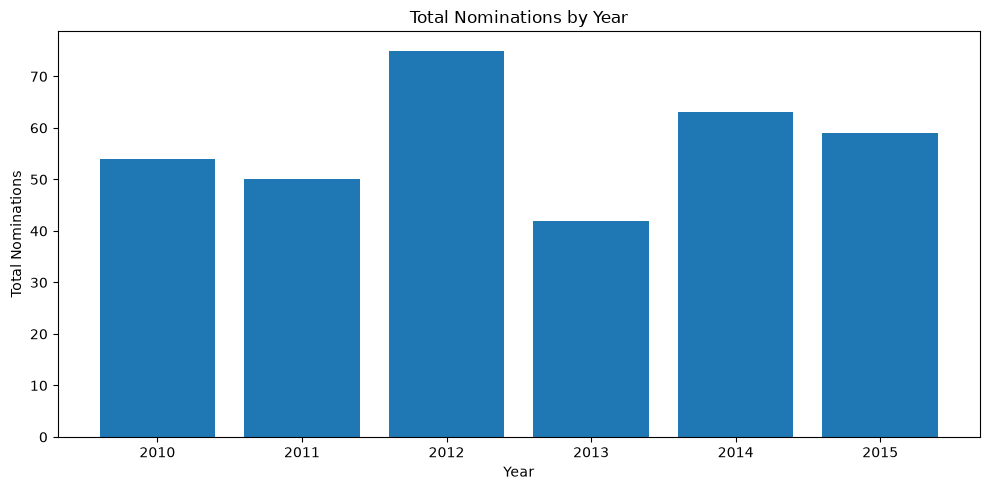

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(
    yearly_summary["year"].astype(str),
    yearly_summary["total_nominations"]
)

plt.title("Total Nominations by Year")
plt.xlabel("Year")
plt.ylabel("Total Nominations")
plt.tight_layout()
plt.show()

## Key Insights

- The dataset contains 87 movies collected from 2010 to 2015.
- 2014 and 2015 had the highest number of movies, with 16 movies each.
- 2012 recorded the highest total awards, with 25 awards.
- 2012 also recorded the highest total nominations, with 75 nominations.
- Gravity received the highest number of awards in the dataset, with 7 awards and 10 nominations.
- Awards and nominations showed a positive correlation of 0.75.
- One Best Picture winner was identified for each year from 2010 to 2015.